In [25]:
import os
os.getcwd()

os.listdir("lightning_logs/mnist_cnn/version_1")

['checkpoints',
 'events.out.tfevents.1785443425.squirrels-iMac.local.1798.6',
 'hparams.yaml',
 'events.out.tfevents.1785443602.squirrels-iMac.local.1798.7',
 'events.out.tfevents.1785443606.squirrels-iMac.local.1798.8']

In [26]:
from tensorboard.backend.event_processing import event_accumulator
import pandas as pd

log_dir = "lightning_logs/mnist_cnn/version_1"

ea = event_accumulator.EventAccumulator(log_dir)
ea.Reload()

ea.Tags()

{'images': [],
 'audio': [],
 'histograms': [],
 'scalars': ['hp_metric',
  'val_loss',
  'val_accuracy',
  'epoch',
  'train_loss',
  'test_accuracy',
  'test_loss'],
 'distributions': [],
 'tensors': [],
 'graph': False,
 'meta_graph': False,
 'run_metadata': []}

In [ ]:
# Plot loss

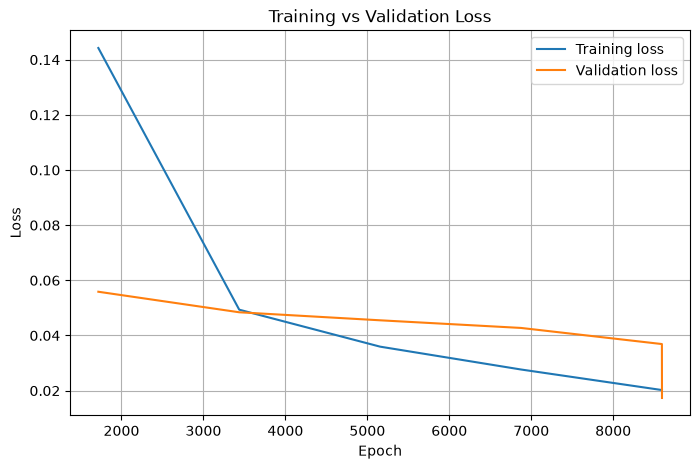

In [27]:
from tensorboard.backend.event_processing import event_accumulator
import matplotlib.pyplot as plt

ea = event_accumulator.EventAccumulator(
    "lightning_logs/mnist_cnn/version_1"
)
ea.Reload()

train_loss = ea.Scalars("train_loss")
val_loss = ea.Scalars("val_loss")

plt.figure(figsize=(8,5))

plt.plot(
    [x.step for x in train_loss],
    [x.value for x in train_loss],
    label="Training loss"
)

plt.plot(
    [x.step for x in val_loss],
    [x.value for x in val_loss],
    label="Validation loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid()

import os
os.makedirs("figures", exist_ok=True)
plt.savefig(
    "figures/training_validation_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# Validation accuracy curve

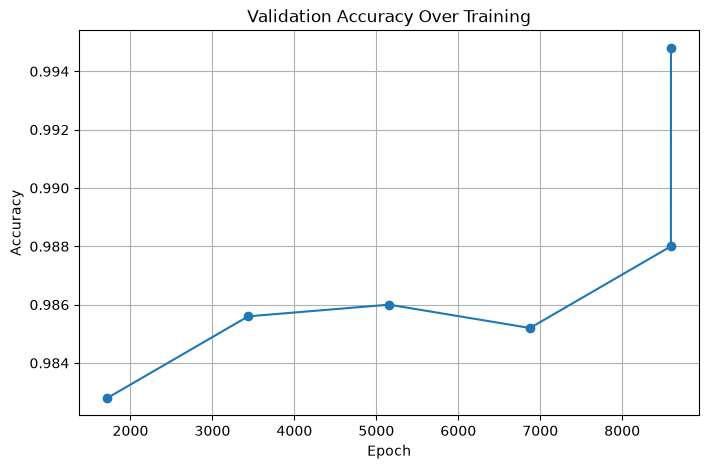

In [28]:
val_acc = ea.Scalars("val_accuracy")

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    [x.step for x in val_acc],
    [x.value for x in val_acc],
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy Over Training")
plt.grid()

plt.savefig(
    "figures/validation_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [ ]:
# Confusion matrix

In [24]:
import os

for root, dirs, files in os.walk("lightning_logs"):
    for f in files:
        if f.endswith(".ckpt"):
            print(os.path.join(root, f))

lightning_logs/version_0/checkpoints/epoch=4-step=8595.ckpt
lightning_logs/mnist_cnn/version_1/checkpoints/epoch=4-step=8595.ckpt
lightning_logs/mnist_cnn/version_0/checkpoints/epoch=2-step=5157.ckpt


In [36]:
import torch
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

from model import Classifier
from data import ImageDataModule


model = Classifier.load_from_checkpoint(
    "lightning_logs/mnist_cnn/version_1/checkpoints/epoch=4-step=8595.ckpt"
)

model.eval()


Classifier(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Linear(in_features=3136, out_features=10, bias=True)
)

In [41]:

datamodule = ImageDataModule()
datamodule.setup()

test_loader = datamodule.test_dataloader()

print(model)

Classifier(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Linear(in_features=3136, out_features=10, bias=True)
)


In [38]:
predictions = []
labels = []

with torch.no_grad():
    for x, y in datamodule.test_dataloader():
        logits = model(x)
        preds = logits.argmax(dim=1)

        predictions.extend(preds.cpu().numpy())
        labels.extend(y.cpu().numpy())

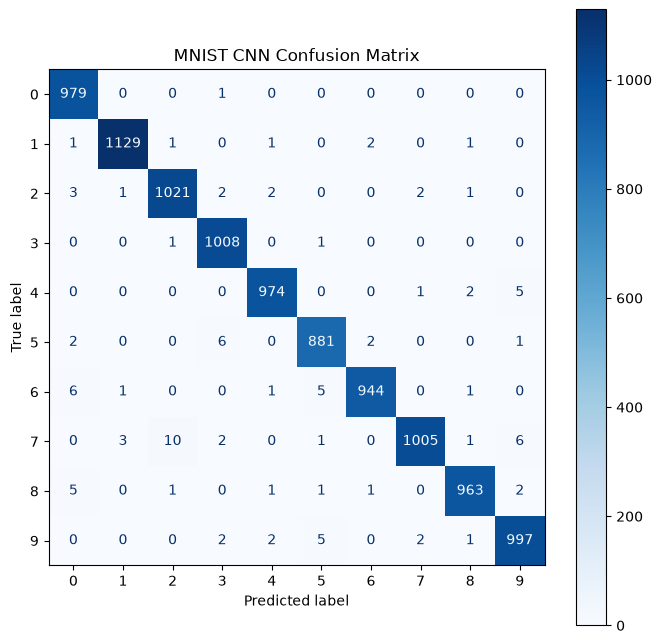

In [39]:
cm = confusion_matrix(labels, predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=range(10)
)

fig, ax = plt.subplots(figsize=(8,8))

disp.plot(
    cmap="Blues",
    ax=ax
)

plt.title("MNIST CNN Confusion Matrix")
plt.savefig(
    "figures/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# Misclassified images

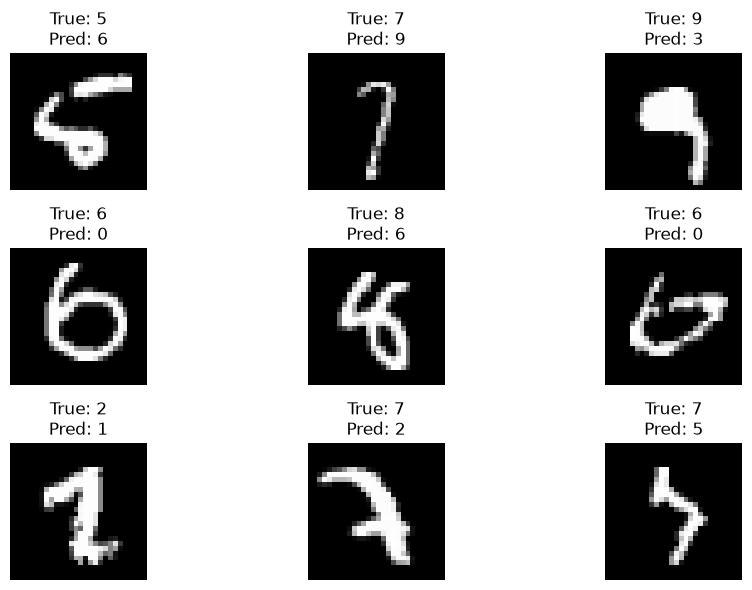

In [43]:
import torch
import matplotlib.pyplot as plt

model.eval()

wrong_images = []
wrong_labels = []
wrong_preds = []



with torch.no_grad():

    for images, labels in datamodule.test_dataloader():

        outputs = model(images)

        preds = torch.argmax(
            outputs,
            dim=1
        )

        for img, label, pred in zip(images, labels, preds):

            if label != pred:

                wrong_images.append(img)
                wrong_labels.append(label.item())
                wrong_preds.append(pred.item())



# Examples


plt.figure(figsize=(10,6))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(
        wrong_images[i].squeeze(),
        cmap="gray"
    )

    plt.title(
        f"True: {wrong_labels[i]}\nPred: {wrong_preds[i]}"
    )

    plt.axis("off")

plt.tight_layout()

plt.savefig(
    "figures/misclassified_digits.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

